In [25]:
# %matplotlib ipympl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import contact_model_plots as cmp
import contact_model_plots_pfc as cmppfc

In [26]:
# settings
experiment = 1
kn_ks = 1

In [27]:

# getting data
# Physics Sim
df = pd.read_csv(f"experiment_{experiment}_{kn_ks}.csv",delimiter=",")
df = df.astype(float)
df["Timestamp"] = df["Timestamp"]  - df["Timestamp"][0]
# PFC
df2 = pd.read_fwf(f"histories/experiment_{experiment}_{kn_ks}.his",delimiter=" ")
df2 = df2.drop(df2.index[0])
df2 = df2.astype(float)
df2.columns = ["Step", "Time(s)", "x_pos", "y_pos", "theta", "x_vel", "y_vel", "omega", "c_nforce", "c_sforce", "c_moment", "c_normal_y_dir", "c_normal_x_dir"]
df2 = df2[df2["Time(s)"] > 0.0005]
df2["Time(s)"] = df2["Time(s)"] - 0.0005


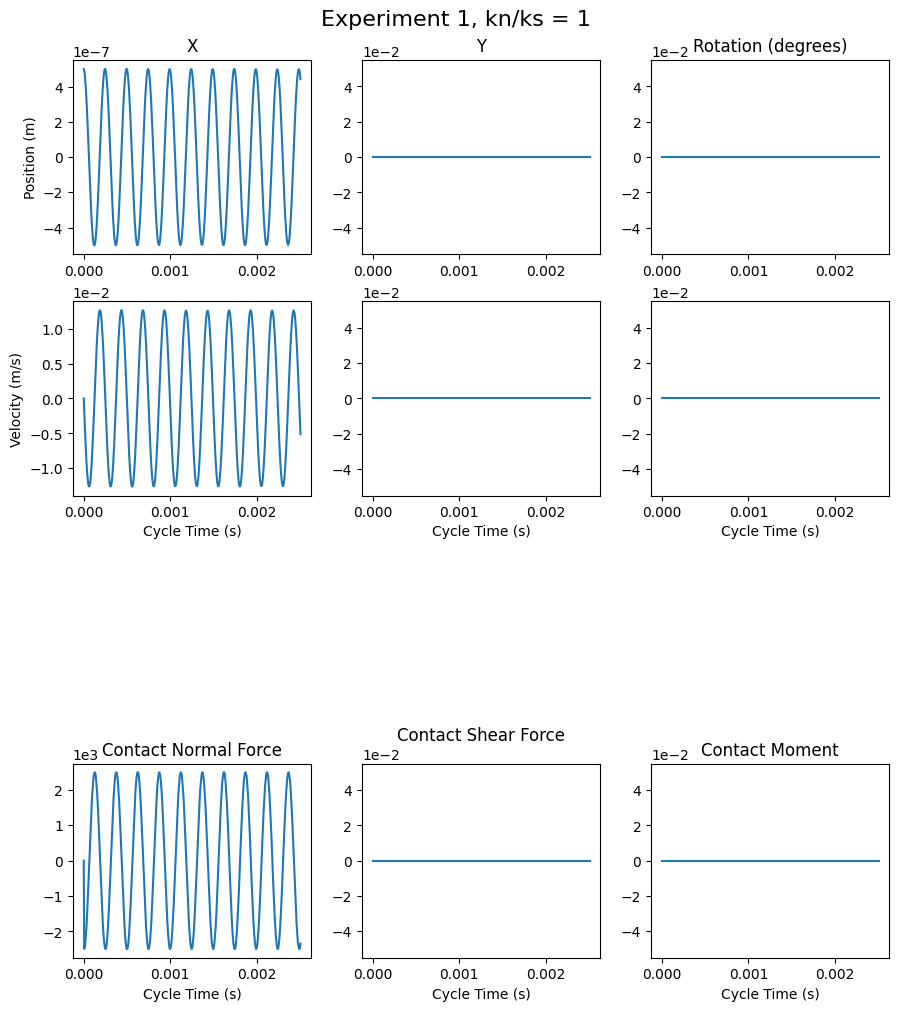

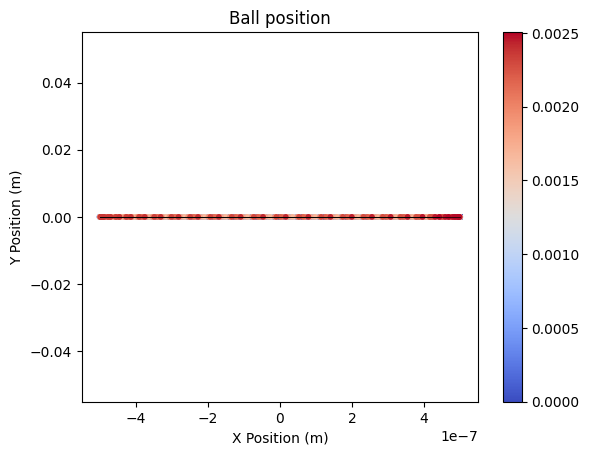

In [28]:
# Plot Physics Sim Data
cmp.bond_behavior_plots(df,experiment,kn_ks)

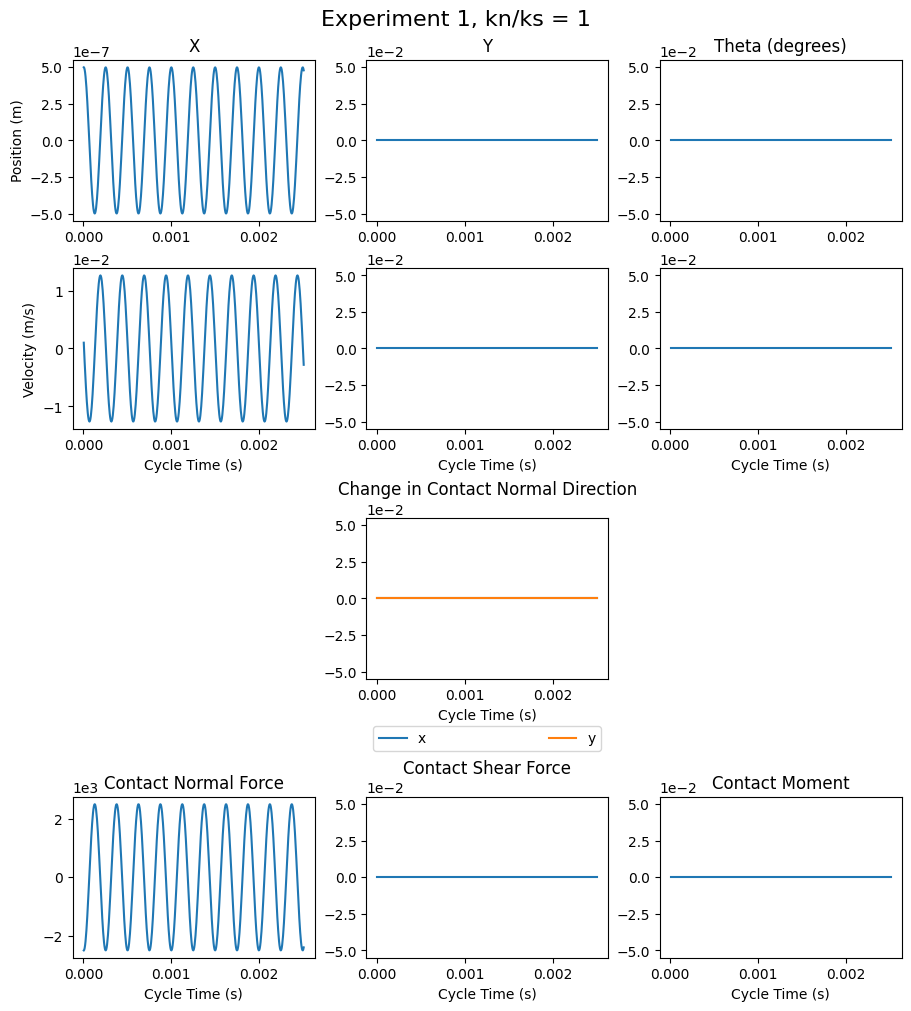

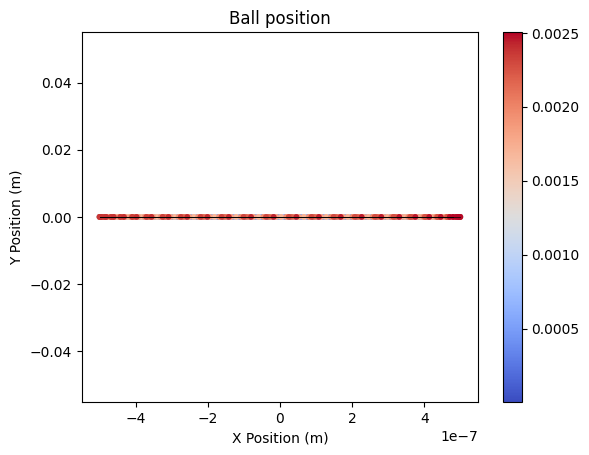

In [29]:
# Plot PFC Data
cmppfc.bond_behavior_plots(df2,experiment,kn_ks)


Text(0.5, 1.0, 'Ball position')

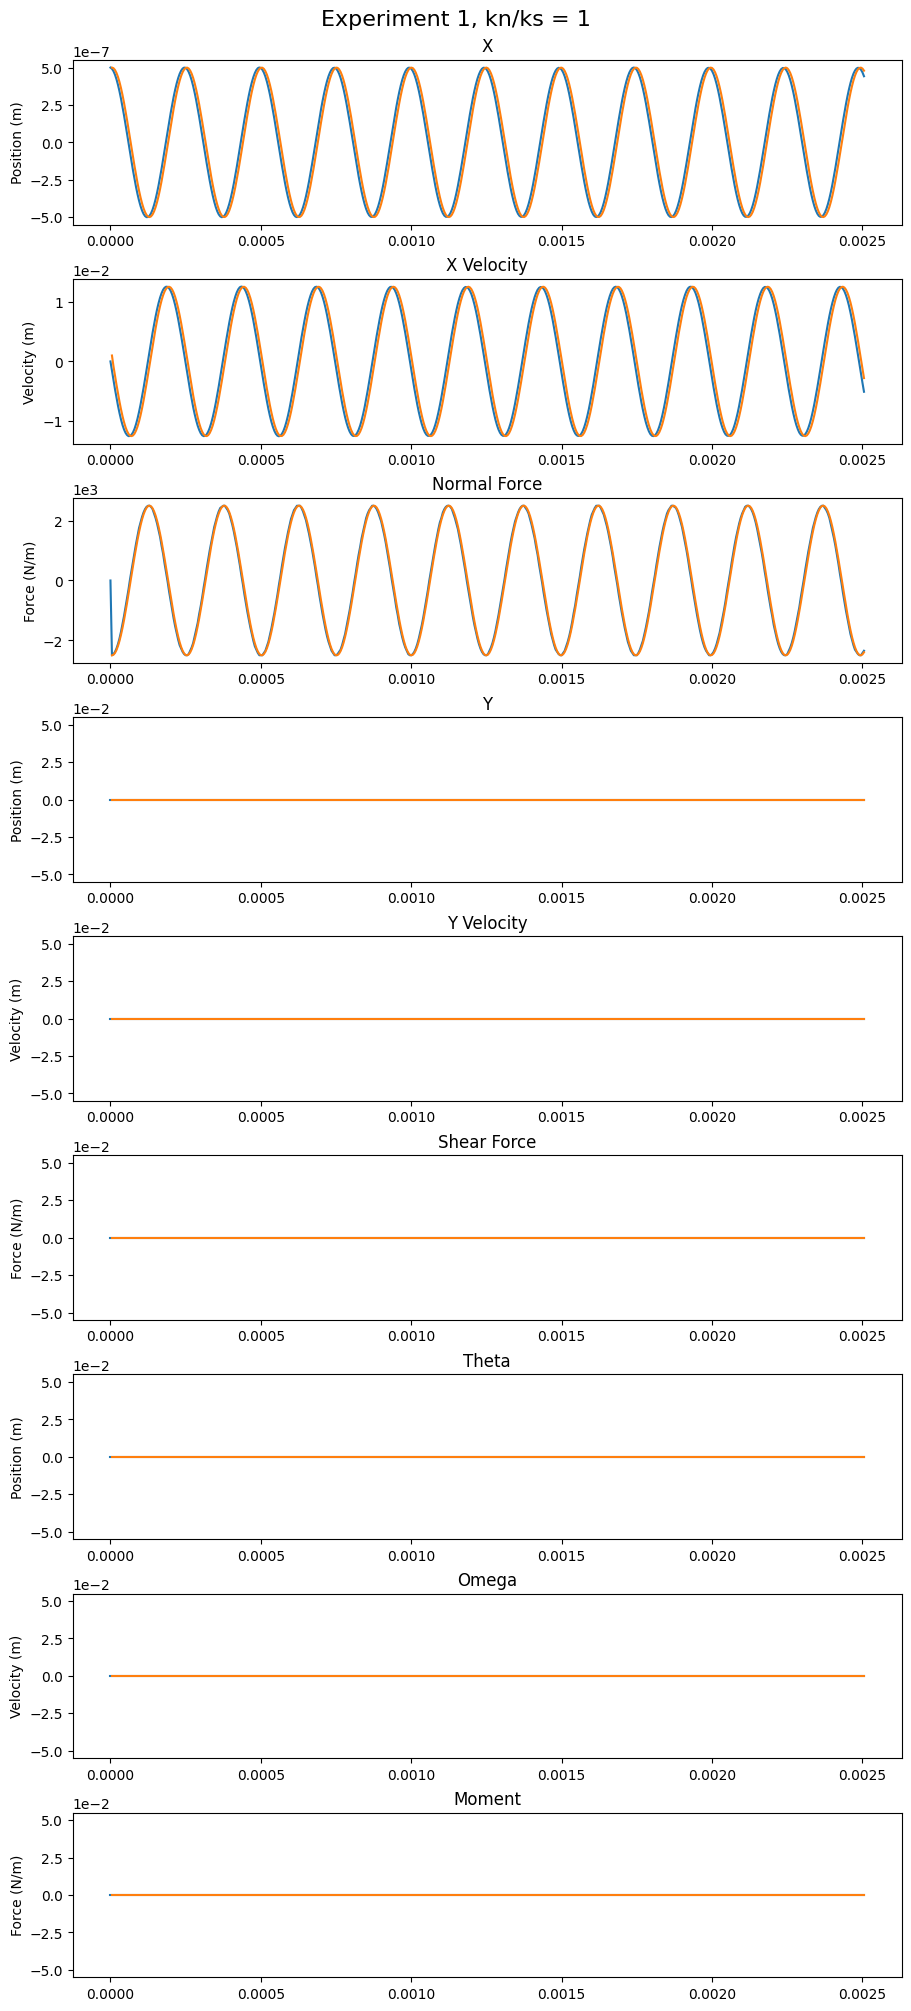

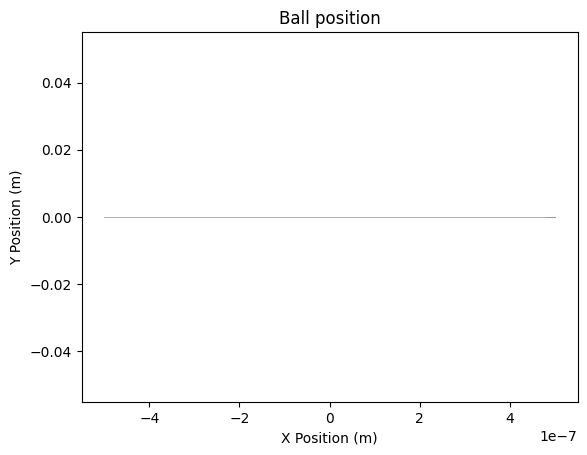

In [31]:
# Plot all data overlapping

plt.close('all')
fig = plt.figure(figsize=(9,20), constrained_layout=True)
fig.suptitle(f'Experiment {experiment}, kn/ks = {kn_ks}', fontsize=16)
gs = fig.add_gridspec(9, 1)

# X Position
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_ylabel('Position (m)')
ax1.plot(df["Timestamp"], df["X Position"])
ax1.plot(df2["Time(s)"], df2["x_pos"])
ax1.set_title('X')

# X Velocity
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_ylabel('Velocity (m)')
ax2.plot(df["Timestamp"], df["X Velocity"])
ax2.plot(df2["Time(s)"], df2["x_vel"])
ax2.set_title('X Velocity')

# Normal Force
ax3 = fig.add_subplot(gs[2, 0])
ax3.set_ylabel('Force (N/m)')
ax3.plot(df["Timestamp"], df["Data1"])
ax3.plot(df2["Time(s)"], df2["c_nforce"])
ax3.set_title('Normal Force')

# Y Position
ax4 = fig.add_subplot(gs[3, 0])
ax4.set_ylabel('Position (m)')
ax4.plot(df["Timestamp"], df["Y Position"])
ax4.plot(df2["Time(s)"], df2["y_pos"])
ax4.set_title('Y')

# Y Velocity
ax5 = fig.add_subplot(gs[4, 0])
ax5.set_ylabel('Velocity (m)')
ax5.plot(df["Timestamp"], df["Y Velocity"])
ax5.plot(df2["Time(s)"], df2["y_vel"])
ax5.set_title('Y Velocity')

# Shear Force
ax6 = fig.add_subplot(gs[5, 0])
ax6.set_ylabel('Force (N/m)')
ax6.plot(df["Timestamp"], df["Data2"])
ax6.plot(df2["Time(s)"], df2["c_sforce"])
ax6.set_title('Shear Force')

# Theta
ax7 = fig.add_subplot(gs[6, 0])
ax7.set_ylabel('Position (m)')
ax7.plot(df["Timestamp"], df["Rotation"])
ax7.plot(df2["Time(s)"], df2["theta"])
ax7.set_title('Theta')

# Omega
ax8 = fig.add_subplot(gs[7, 0])
ax8.set_ylabel('Velocity (m)')
ax8.plot(df["Timestamp"], df["Rotation Velocity"])
ax8.plot(df2["Time(s)"], df2["omega"])
ax8.set_title('Omega')

# Moment
ax9 = fig.add_subplot(gs[8, 0])
ax9.set_ylabel('Force (N/m)')
ax9.plot(df["Timestamp"], df["Data3"])
ax9.plot(df2["Time(s)"], df2["c_moment"])
ax9.set_title('Moment')

ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax5.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax6.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax7.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax8.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax9.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

fig2, ax = plt.subplots()
ax.plot(df["X Position"], df["Y Position"], linewidth=0.5, c='blue')
# pos = ax.scatter(df["X Position"], df["Y Position"], s=10, c=df["Timestamp"], cmap='warmcool')
# fig2.colorbar(pos, ax=ax)
ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_title('Ball position')

ax.plot(df2["x_pos"], df2["y_pos"], linewidth=0.5, c='orange')
# pos = ax.scatter(df2["x_pos"], df2["y_pos"], s=10, c=df2["Time(s)"], cmap='coolwarm')
# fig2.colorbar(pos, ax=ax)
ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_title('Ball position')